# 6. Protocolos de evaluación: cuantificación del efecto de la fuga

**Qué responde este notebook.** La bibliografía sobre DAIC-WOZ reporta con frecuencia métricas muy
superiores a las obtenidas en este trabajo. Una explicación documentada es que **el protocolo de
evaluación difiere**: numerosos estudios reparten los *segmentos* de audio de forma aleatoria, de
modo que fragmentos de un mismo hablante quedan simultáneamente en entrenamiento y test
(*speaker leakage*). El estudio controlado de referencia cuantifica el efecto en **~20 puntos de
F1** (≈0.70 con solapamiento frente a ≈0.50 sin él), empleando **solo variables acústicas**.

Aquí se reproduce el fenómeno **sobre el pipeline de este trabajo**, manteniendo constantes modelo,
variables e hiperparámetros, y variando **únicamente el protocolo**:

| | Partición | Variables | Métrica | Qué representa |
|---|---|---|---|---|
| **A** | Por sujeto (split oficial) | Todas | **Sujeto** | Protocolo honesto — el del resto del TFE |
| **B** | Por sujeto | Todas | Ventana | Control: aísla el efecto del *nivel* de la métrica |
| **C** | **Aleatoria de ventanas** | Todas | Ventana | Fuga por **identificador de sesión** |
| **D** | **Aleatoria de ventanas** | **Solo acústicas** | Ventana | Fuga por **identidad de hablante** (la de la literatura) |

**Por qué son necesarios C y D por separado.** Las 14 variables de turnos y pausas son de sesión y
se difunden idénticas a todas las ventanas de un mismo sujeto; cada una toma **186 valores
distintos, uno por sesión**, de modo que **funcionan como una clave primaria**. Bajo partición
aleatoria, el modelo no necesita aprender nada acústico: le basta con memorizar la correspondencia
valor→etiqueta. El protocolo **D elimina esas variables** y deja solo acústicas por ventana, de
forma que la única fuga posible es la **identidad vocal** del hablante — que es exactamente el
mecanismo descrito en la literatura.

**Ajuste del umbral.** En cada protocolo el umbral de decisión se ajusta sobre un conjunto de
**validación propio** (nunca sobre test), maximizando el F1 de la clase deprimida. Sin esto la
comparación sería injusta: un umbral fijo de 0.5 penaliza al protocolo A, cuyas probabilidades
promediadas por sujeto se comprimen hacia la media.

> **Advertencia.** Los protocolos C y D son **incorrectos** para estimar capacidad de
> generalización y se incluyen **exclusivamente como demostración cuantitativa**. El rendimiento
> del sistema que se reporta en este trabajo es siempre el del **protocolo A**.

## 0. Setup y datos

In [8]:
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_recall_fscore_support, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_df = PROJECT_DIR + '/output/df_segment_features_vf.csv'
PHQ_THRESHOLD, RANDOM_STATE, K_FEATURES = 10, 42, 20
GROUP = 'participant_id'
NON_FEATURE = ['participant_id', 'phq8_binary', 'phq8_score', 'split', 'window_idx']
ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

df = pd.read_csv(path_df)
COLS_ALL      = [c for c in df.columns if c not in NON_FEATURE]              # 60 (incl. gender)
ACOUSTIC_COLS = [c for c in COLS_ALL if c.startswith(ACOUSTIC_PREFIXES)]     # 45
PAUSE_COLS    = [c for c in COLS_ALL if c.endswith('_pat')]                  # 14
COLS_ACOUSTIC = ACOUSTIC_COLS + ['gender']        # solo acusticas (+gender para normalizar)
df['y'] = (df['phq8_score'] >= PHQ_THRESHOLD).astype(int)

print(f"Ventanas {len(df)} | sesiones {df[GROUP].nunique()} | prevalencia {df['y'].mean():.3f}")
print(f"Variables: {len(COLS_ALL)} totales = {len(ACOUSTIC_COLS)} acústicas + {len(PAUSE_COLS)} pausas + gender")

Ventanas 19009 | sesiones 186 | prevalencia 0.313
Variables: 60 totales = 45 acústicas + 14 pausas + gender


## 1. Comprobación: las variables de pausas identifican unívocamente la sesión
Antes de interpretar nada, se verifica el mecanismo que motiva separar los protocolos C y D.

In [9]:
nun = df.groupby(GROUP)[PAUSE_COLS].nunique().max().max()
combos = len(df[PAUSE_COLS].drop_duplicates())
print(f"Valores distintos por sesión en las variables de pausas: {nun}  (1 = constante)")
print(f"Combinaciones únicas de las 14 variables: {combos} | sesiones: {df[GROUP].nunique()}")
for c in PAUSE_COLS[:3]:
    print(f"   {c}: {df[c].nunique()} valores distintos")
print("\n-> Cada variable de pausa toma un valor único por sesión: actúan como CLAVE PRIMARIA.")
print("   Bajo partición aleatoria permiten memorizar la etiqueta sin aprender nada acústico.")

Valores distintos por sesión en las variables de pausas: 1  (1 = constante)
Combinaciones únicas de las 14 variables: 186 | sesiones: 186
   nTurns_pat: 48 valores distintos
   sumTurns_pat: 186 valores distintos
   avgTurns_pat: 186 valores distintos

-> Cada variable de pausa toma un valor único por sesión: actúan como CLAVE PRIMARIA.
   Bajo partición aleatoria permiten memorizar la etiqueta sin aprender nada acústico.


## 2. Modelo y utilidades (idénticos en los cuatro protocolos)

In [10]:
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    def __init__(self, cols, gender_col='gender'):
        self.cols = cols; self.gender_col = gender_col
    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            self.stats_[g] = (sub[self.cols].mean(), sub[self.cols].std(ddof=0).replace(0, 1.0))
        self.global_ = (X[self.cols].mean(), X[self.cols].std(ddof=0).replace(0, 1.0))
        return self
    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X.drop(columns=[c for c in self.cols if c in X.columns])

def build_model(k=K_FEATURES):
    return Pipeline([
        ('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
        ('dropgender', DropColumns(['gender'])),
        ('imputer',    SimpleImputer(strategy='median')),
        ('scaler',     StandardScaler()),
        ('select',     SelectKBest(f_classif, k=k)),
        ('rf',         RandomForestClassifier(n_estimators=330, max_depth=8,
                                              min_samples_leaf=13, min_samples_split=33,
                                              max_features='log2', class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1)),
    ])

def best_threshold(y_val, p_val):
    """Umbral que maximiza el F1 de la clase deprimida en VALIDACIÓN (nunca en test)."""
    ths = np.linspace(0.05, 0.95, 181)
    return ths[int(np.argmax([f1_score(y_val, (p_val >= t).astype(int), zero_division=0)
                              for t in ths]))]

def report(y_true, prob, thr):
    yh = (prob >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_true, yh, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, yh).ravel()
    _, _, bf, _ = precision_recall_fscore_support(y_true, np.ones(len(y_true)),
                                                  average='binary', zero_division=0)
    return dict(n=len(y_true), thr=round(float(thr), 2), AUC=roc_auc_score(y_true, prob),
                Prec=p, Rec=r, F1=f, Acc=accuracy_score(y_true, yh), F1_trivial=bf,
                TP=tp, FP=fp, FN=fn, TN=tn)

## 3. Protocolos A y B — partición por sujeto (split oficial)
Se entrena con las ventanas de `train`, se ajusta el umbral en `dev` y se evalúa en `test`.
Ningún sujeto aparece en más de una partición. A agrega las predicciones a sujeto; B las evalúa
ventana a ventana con el mismo modelo.

In [11]:
tr = (df['split'] == 'train').values
dv = (df['split'] == 'dev').values
te = (df['split'] == 'test').values
assert not (set(df[GROUP][tr]) & set(df[GROUP][te])), 'FUGA entre train y test'
print(f"Ventanas -> train {tr.sum()} | dev {dv.sum()} | test {te.sum()}")

m = build_model().fit(df.loc[tr, COLS_ALL], df.loc[tr, 'y'])
p_dv, p_te = (m.predict_proba(df.loc[dv, COLS_ALL])[:, 1],
              m.predict_proba(df.loc[te, COLS_ALL])[:, 1])

def to_subject(mask, prob):
    return (pd.DataFrame({'pid': df.loc[mask, GROUP].values, 'p': prob,
                          'y': df.loc[mask, 'y'].values})
            .groupby('pid').agg(p=('p', 'mean'), y=('y', 'first')))

# --- A: metrica a nivel de sujeto (umbral ajustado sobre dev agregado) ---
sdv, ste = to_subject(dv, p_dv), to_subject(te, p_te)
res_A = report(ste['y'].values, ste['p'].values, best_threshold(sdv['y'].values, sdv['p'].values))

# --- B: metrica a nivel de ventana (umbral ajustado sobre dev por ventana) ---
res_B = report(df.loc[te, 'y'].values, p_te, best_threshold(df.loc[dv, 'y'].values, p_dv))

print('A) sujeto-indep. + SUJETO :', {k: (round(v,3) if isinstance(v,float) else v) for k,v in res_A.items()})
print('B) sujeto-indep. + ventana:', {k: (round(v,3) if isinstance(v,float) else v) for k,v in res_B.items()})

Ventanas -> train 10203 | dev 3591 | test 5215
A) sujeto-indep. + SUJETO : {'n': 46, 'thr': 0.26, 'AUC': 0.714, 'Prec': 0.378, 'Rec': 1.0, 'F1': 0.549, 'Acc': 0.5, 'F1_trivial': 0.467, 'TP': 14, 'FP': 23, 'FN': 0, 'TN': 9}
B) sujeto-indep. + ventana: {'n': 5215, 'thr': 0.23, 'AUC': 0.739, 'Prec': 0.363, 'Rec': 0.997, 'F1': 0.532, 'Acc': 0.525, 'F1_trivial': 0.427, 'TP': 1410, 'FP': 2473, 'FN': 4, 'TN': 1328}


## 4. Protocolos C y D — partición ALEATORIA de ventanas (con fuga)
Se ignora la pertenencia a sujeto y se reparten las ventanas al azar (60 / 15 / 25). Fragmentos de
un mismo hablante caen a la vez en entrenamiento, validación y test. **C** usa todas las variables
(incluidas las de pausas, que identifican la sesión); **D** usa solo las acústicas por ventana, de
modo que la única fuga posible es la identidad vocal.

In [12]:
idx = np.arange(len(df)); yv = df['y'].values
i_tr, i_tmp = train_test_split(idx,   test_size=0.40, stratify=yv,        random_state=RANDOM_STATE)
i_dv, i_te  = train_test_split(i_tmp, test_size=0.625, stratify=yv[i_tmp], random_state=RANDOM_STATE)

n_solap = len(set(df[GROUP].values[i_tr]) & set(df[GROUP].values[i_te]))
print(f"Sujetos presentes en train Y test a la vez: {n_solap} de {df[GROUP].nunique()}  <- la fuga")
print(f"Ventanas -> train {len(i_tr)} | val {len(i_dv)} | test {len(i_te)}\n")

res = {}
for nombre, cols, k in [('C', COLS_ALL, K_FEATURES), ('D', COLS_ACOUSTIC, K_FEATURES)]:
    mm = build_model(k=k).fit(df.iloc[i_tr][cols], df.iloc[i_tr]['y'])
    pv = mm.predict_proba(df.iloc[i_dv][cols])[:, 1]
    pt = mm.predict_proba(df.iloc[i_te][cols])[:, 1]
    res[nombre] = report(df.iloc[i_te]['y'].values, pt, best_threshold(df.iloc[i_dv]['y'].values, pv))
res_C, res_D = res['C'], res['D']
print('C) aleatorio + TODAS  (id. de sesión) :', {k:(round(v,3) if isinstance(v,float) else v) for k,v in res_C.items()})
print('D) aleatorio + acústicas (voz)        :', {k:(round(v,3) if isinstance(v,float) else v) for k,v in res_D.items()})

Sujetos presentes en train Y test a la vez: 186 de 186  <- la fuga
Ventanas -> train 11405 | val 2851 | test 4753

C) aleatorio + TODAS  (id. de sesión) : {'n': 4753, 'thr': 0.52, 'AUC': 1.0, 'Prec': 0.998, 'Rec': 1.0, 'F1': 0.999, 'Acc': 0.999, 'F1_trivial': 0.476, 'TP': 1486, 'FP': 3, 'FN': 0, 'TN': 3264}
D) aleatorio + acústicas (voz)        : {'n': 4753, 'thr': 0.43, 'AUC': 0.749, 'Prec': 0.437, 'Rec': 0.79, 'F1': 0.562, 'Acc': 0.616, 'F1_trivial': 0.476, 'TP': 1174, 'FP': 1515, 'FN': 312, 'TN': 1752}


## 5. Comparación de los cuatro protocolos

In [13]:
tabla = pd.DataFrame({
    'A) Sujeto-indep. + sujeto   (HONESTO)':      res_A,
    'B) Sujeto-indep. + ventana  (control)':      res_B,
    'C) Aleatorio, todas    (fuga por ID)':       res_C,
    'D) Aleatorio, acústicas (fuga de voz)':      res_D,
}).T[['n','thr','AUC','Prec','Rec','F1','Acc','F1_trivial','TP','FP','FN','TN']]
for c in ['AUC','Prec','Rec','F1','Acc','F1_trivial']:
    tabla[c] = tabla[c].astype(float).round(3)
print('Mismo modelo, mismos hiperparámetros. Solo cambian partición y variables.\n')
tabla

Mismo modelo, mismos hiperparámetros. Solo cambian partición y variables.



,n,thr,AUC,Prec,Rec,F1,Acc,F1_trivial,TP,FP,FN,TN
A) Sujeto-indep. + sujeto (HONESTO),46.0,0.26,0.714,0.378,1.000,0.549,0.500,0.467,14.0,23.0,0.0,9.0
B) Sujeto-indep. + ventana (control),5215.0,0.23,0.739,0.363,0.997,0.532,0.525,0.427,1410.0,2473.0,4.0,1328.0
"C) Aleatorio, todas (fuga por ID)",4753.0,0.52,1.000,0.998,1.000,0.999,0.999,0.476,1486.0,3.0,0.0,3264.0
"D) Aleatorio, acústicas (fuga de voz)",4753.0,0.43,0.749,0.437,0.790,0.562,0.616,0.476,1174.0,1515.0,312.0,1752.0


In [14]:
print('DESCOMPOSICIÓN DEL EFECTO (en F1)')
print(f"  Nivel de la métrica      A -> B : {res_B['F1']-res_A['F1']:+.3f}")
print(f"  Fuga por identidad vocal B -> D : {res_D['F1']-res_B['F1']:+.3f}   <- mecanismo de la literatura")
print(f"  Fuga por identificador   D -> C : {res_C['F1']-res_D['F1']:+.3f}   <- artefacto de las variables de sesión")
print(f"  TOTAL                    A -> C : {res_C['F1']-res_A['F1']:+.3f}")
print(f"\nReferencia (estudio controlado, solo acústicas): ~+0.20 F1 por solapamiento de hablante")
print(f"Obtenido aquí en condiciones equivalentes (B->D): {res_D['F1']-res_B['F1']:+.3f} F1")

DESCOMPOSICIÓN DEL EFECTO (en F1)
  Nivel de la métrica      A -> B : -0.017
  Fuga por identidad vocal B -> D : +0.030   <- mecanismo de la literatura
  Fuga por identificador   D -> C : +0.437   <- artefacto de las variables de sesión
  TOTAL                    A -> C : +0.450

Referencia (estudio controlado, solo acústicas): ~+0.20 F1 por solapamiento de hablante
Obtenido aquí en condiciones equivalentes (B->D): +0.030 F1


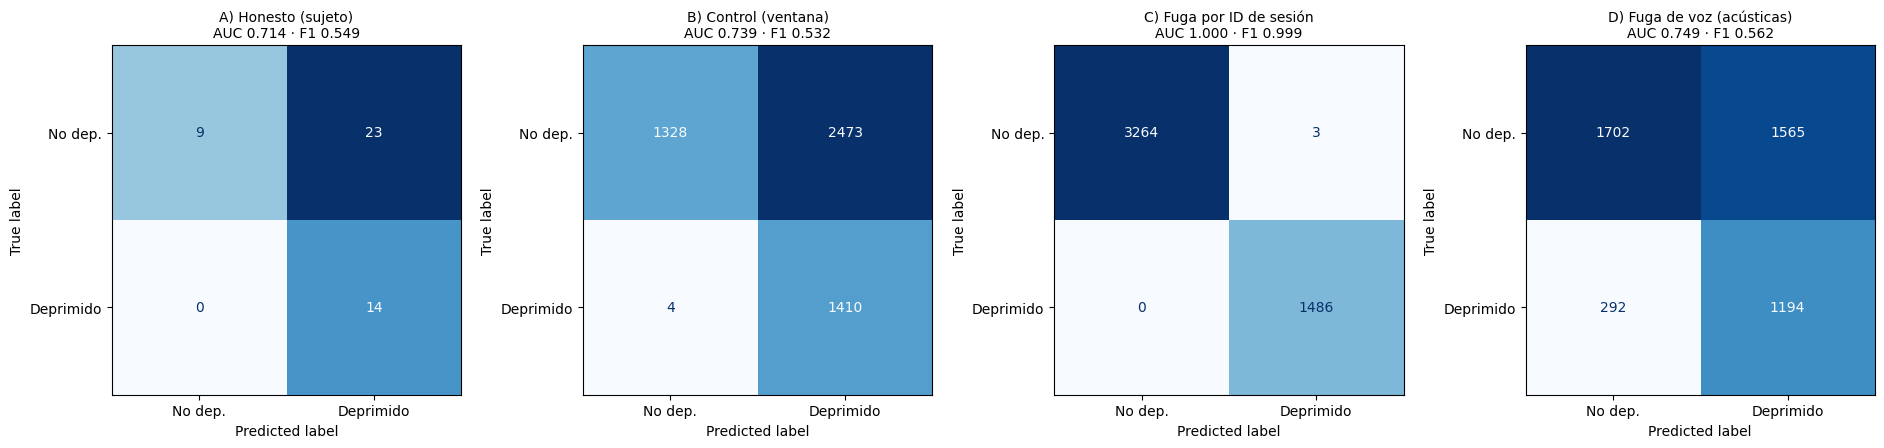

In [15]:
# Matrices de confusion en CONTEO NETO de casos (sin normalizar)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
paneles = [
    ('A) Honesto (sujeto)',        res_A, ste['y'].values,             ste['p'].values),
    ('B) Control (ventana)',       res_B, df.loc[te, 'y'].values,      p_te),
    ('C) Fuga por ID de sesión',   res_C, df.iloc[i_te]['y'].values,   None),
    ('D) Fuga de voz (acústicas)', res_D, df.iloc[i_te]['y'].values,   None),
]
# recomputar probabilidades de C y D para las matrices
for nombre, cols in [('C', COLS_ALL), ('D', COLS_ACOUSTIC)]:
    mm = build_model().fit(df.iloc[i_tr][cols], df.iloc[i_tr]['y'])
    pt = mm.predict_proba(df.iloc[i_te][cols])[:, 1]
    j = 2 if nombre == 'C' else 3
    paneles[j] = (paneles[j][0], paneles[j][1], paneles[j][2], pt)

for ax, (titulo, r, y_true, prob) in zip(axes, paneles):
    ConfusionMatrixDisplay.from_predictions(
        y_true, (prob >= r['thr']).astype(int),
        display_labels=['No dep.', 'Deprimido'], colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(f"{titulo}\nAUC {r['AUC']:.3f} · F1 {r['F1']:.3f}", fontsize=10)
plt.tight_layout(); plt.show()

## 6. Lectura

- **A vs D** es la comparación relevante frente a la literatura: la diferencia procede
  exclusivamente del solapamiento de hablante, con variables acústicas en ambos casos. El orden de
  magnitud obtenido debe contrastarse con los ~20 puntos de F1 del estudio de referencia.
- **C** muestra un mecanismo adicional y más severo: cuando variables constantes por sesión se
  difunden a las ventanas, actúan como identificador y permiten **memorizar la etiqueta** sin
  aprender nada del habla. Un rendimiento cercano a la perfección bajo partición aleatoria **no es
  indicio de un buen modelo, sino de un protocolo inválido**.
- La diferencia **A vs B** no es fuga: refleja que evaluar por ventana y por sujeto no son la misma
  tarea (distinto número de unidades y distinta dificultad). Se incluye para que la comparación con
  cifras publicadas a nivel de segmento sea interpretable.
- Ambos hallazgos explican por qué los resultados honestos de este trabajo se sitúan por debajo de
  buena parte de la bibliografía **sin que ello implique un modelo inferior**.